# Install Required Libraries

In [2]:
pip install numpy pandas scikit-learn matplotlib seaborn tensorflow keras flask

Note: you may need to restart the kernel to use updated packages.


# Step 2: Data Collection & Preprocessing

## 1. Load the Dataset

In [5]:
import pandas as pd

# Load dataset
df = pd.read_csv("creditcard.csv")

# Display the first few rows
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

## 2. Explore the Dataset

In [7]:
# Check dataset info
print(df.info())

# Check for missing values
print(df.isnull().sum())

# Check class distribution (fraud vs. non-fraud)
print(df["Class"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## Feature Scaling & Normalization

In [9]:
from sklearn.preprocessing import StandardScaler

# Standardize the 'Amount' column
scaler = StandardScaler()
df["Amount"] = scaler.fit_transform(df["Amount"].values.reshape(-1, 1))

# Drop 'Time' column as it's not needed
df.drop("Time", axis=1, inplace=True)

print(df.head())

         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V21       V22       V23       V24  \
0  0.098698  0.363787  0.090794  ... -0.018307  0.277838 -0.110474  0.066928   
1  0.085102 -0.255425 -0.166974  ... -0.225775 -0.638672  0.101288 -0.339846   
2  0.247676 -1.514654  0.207643  ...  0.247998  0.771679  0.909412 -0.689281   
3  0.377436 -1.387024 -0.054952  ... -0.108300  0.005274 -0.190321 -1.175575   
4 -0.270533  0.817739  0.753074  ... -0.009431  0.798278 -0.137458  0.141267   

        V25       V26       V27       V28    Amount  Class  
0  0.12

# Step 3: Splitting the Data & Training a Model

## 1. Splitting the Data

In [12]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop("Class", axis=1)
y = df["Class"]

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Check the shape of training and testing sets
print(f"Training set: {X_train.shape}, Testing set: {X_test.shape}")

Training set: (227845, 29), Testing set: (56962, 29)


## 2. Training a Logistic Regression Model

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9991573329588147

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



# Step 4: Evaluating the Model & Handling Imbalanced Data

## 1. Understanding the Evaluation Metrics

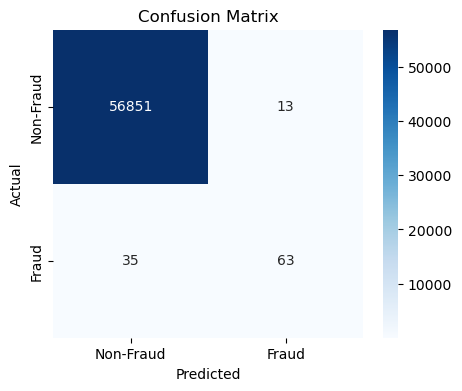

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Fraud", "Fraud"], yticklabels=["Non-Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 2. Handling Imbalanced Data

In [19]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check new class distribution
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_resampled).value_counts())

Before SMOTE: Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64


## 3. Retraining the Model with SMOTE

In [21]:
# Train the model on balanced data
model.fit(X_train_resampled, y_train_resampled)

# Predict again
y_pred_resampled = model.predict(X_test)

# Evaluate again
print("Accuracy:", accuracy_score(y_test, y_pred_resampled))
print("\nClassification Report:\n", classification_report(y_test, y_pred_resampled))

Accuracy: 0.9733682103858713

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962



# Step 5: Trying Different Machine Learning Models

## 1. Training a Random Forest Model

In [24]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on SMOTE-balanced data
rf_model.fit(X_train_resampled, y_train_resampled)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate performance
print("\nRandom Forest Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Model Evaluation:
Accuracy: 0.9994908886626171

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



## 2. Training an XGBoost Model

In [26]:
from xgboost import XGBClassifier

# Initialize the XGBoost model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Train the model on SMOTE-balanced data
xgb_model.fit(X_train_resampled, y_train_resampled)

# Predict on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate performance
print("\nXGBoost Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

C:\Users\LIKITH\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:12:36] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost Model Evaluation:
Accuracy: 0.9990871107053826

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.69      0.87      0.77        98

    accuracy                           1.00     56962
   macro avg       0.84      0.93      0.88     56962
weighted avg       1.00      1.00      1.00     56962



## 3. Comparing Model Performances

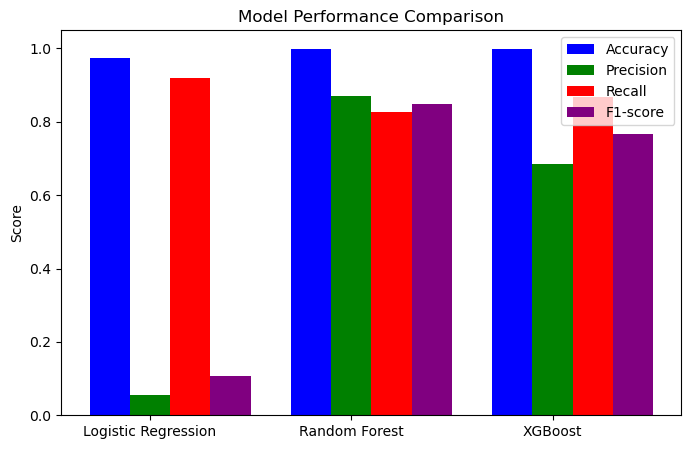

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Store results
models = ["Logistic Regression", "Random Forest", "XGBoost"]
accuracies = [
    accuracy_score(y_test, y_pred_resampled),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_xgb)
]
precisions = [
    precision_score(y_test, y_pred_resampled),
    precision_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_xgb)
]
recalls = [
    recall_score(y_test, y_pred_resampled),
    recall_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_xgb)
]
f1_scores = [
    f1_score(y_test, y_pred_resampled),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_xgb)
]

# Plot comparison
x = np.arange(len(models))
plt.figure(figsize=(8,5))
plt.bar(x - 0.2, accuracies, 0.2, label='Accuracy', color='blue')
plt.bar(x, precisions, 0.2, label='Precision', color='green')
plt.bar(x + 0.2, recalls, 0.2, label='Recall', color='red')
plt.bar(x + 0.4, f1_scores, 0.2, label='F1-score', color='purple')

plt.xticks(x, models)
plt.ylabel("Score")
plt.legend()
plt.title("Model Performance Comparison")
plt.show()

# Saving & Deploying the Model for Real-Time Fraud Detection

## 1. Save the Trained Model

In [31]:
import joblib

# Save the best model (Replace rf_model with xgb_model if XGBoost performed better)
joblib.dump(rf_model, "fraud_detection_model.pkl")

print("Model saved successfully!")

Model saved successfully!


## 2. Load & Test the Saved Model

In [33]:
# Load the saved model
loaded_model = joblib.load("fraud_detection_model.pkl")

# Test with a sample transaction
sample_transaction = X_test.iloc[0].values.reshape(1, -1)  # Reshape for prediction
prediction = loaded_model.predict(sample_transaction)

# Show prediction result
print("Fraud Detected!" if prediction[0] == 1 else "Transaction is Safe.")

Transaction is Safe.


C:\Users\LIKITH\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [49]:
# Get only fraudulent transactions
fraud_transactions = X_test[y_test == 1]

# Display first 5 fraudulent transactions
fraud_transactions.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
77348,-1.271244,2.462675,-2.851395,2.324480,-1.372245,-0.948196,-3.065234,1.166927,-2.268771,-4.881143,...,0.560478,0.652941,0.081931,-0.221348,-0.523582,0.224228,0.756335,0.632800,0.250187,-0.353189
102442,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,-5.052502,...,-3.493050,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,-0.349231
119781,-2.866364,2.346949,-4.053307,3.983359,-3.463186,-1.280953,-4.474764,1.216655,-2.309829,-5.515507,...,0.270013,1.049732,0.475840,0.404480,0.282030,-0.506901,-0.371741,0.615257,0.803163,0.144652
48094,-1.278138,0.716242,-1.143279,0.217805,-1.293890,-1.168952,-2.564182,0.204532,-1.611155,-1.250286,...,0.817203,0.490183,0.470427,-0.126261,-0.126644,-0.661908,-0.349793,0.454851,0.137843,-0.253677
42958,-13.897206,6.344280,-14.281666,5.581009,-12.887133,-3.146176,-15.450467,9.060281,-5.486121,-14.676470,...,-1.025228,3.058082,0.941180,-0.232710,0.763508,0.075456,-0.453840,-1.508968,-0.686836,-0.313289
